In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import torch
import torch.nn as nn
import torch 
import os
import torch_geometric as pyg

from complex2.models.ComplEx2 import ComplEx2
from complex2.data.TriplesDataset import TriplesDataset

from lincs_gsnn.utils.eval import filtered_rank
from lincs_gsnn.utils.eval import eval_edge_inference

from sklearn.metrics import roc_auc_score
import networkx as nx


%load_ext autoreload
%autoreload 2

# set random seed 
np.random.seed(42)


/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# GSNN Output Edge Inference Baseline comparisons 

The GSNN OEI method infers function->output edges, by fitting a linear regression between outputs and node activations. Nodes that can predict an output well are considered more likely to have an edge that exists. We have run this method, but need a baseline to compare against. 

Given network (G), inputs X (N_obs, N_genes; exprssion at time T) and outputs Y (N_obs, N_genes; dx/dt at time T), I need to develop a baseline model to infer missing edges, and evaluate on a hold-out test set. 

In [2]:
root_dir = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/default/' 

net_dir = f'{root_dir}/bionetwork/'
out_dir = f'{root_dir}/infer_edges/'

data = torch.load(f'{net_dir}/bionetwork.pt', weights_only=False)
function_node_map = getattr(data, 'function_node_map', None)
edge_index = data.edge_index_dict['function', 'to', 'function']

BATCH_SIZE = 2048
HIDDEN_CHANNELS = 256
LR = 1e-4
N_EPOCHS = 1000


In [3]:
# select some edges to use as a validation set 

val_mask = torch.randint(0, 100, (edge_index.shape[1],)) > 95
sum(val_mask)
train_mask = ~val_mask 

edge_index_train = edge_index[:, train_mask]
edge_index_val = edge_index[:, val_mask]

train_heads, train_tails = edge_index_train[0], edge_index_train[1]
train_relations = torch.zeros(train_heads.shape[0])

val_heads, val_tails = edge_index_val[0], edge_index_val[1]
val_relations = torch.zeros(val_heads.shape[0]) 

train_dataset = TriplesDataset({'head': train_heads, 'tail': train_tails, 'relation': train_relations})
val_dataset = TriplesDataset({'head': val_heads, 'tail': val_tails, 'relation': val_relations})

print('# train_dataset', len(train_dataset))
print('# val_dataset', len(val_dataset))

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


# train_dataset 7524
# val_dataset 293


/home/exacloud/gscratch/mcweeney_lab/evans/complex2/complex2/data/TriplesDataset.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.pos_heads = torch.tensor(triples['head'], dtype=torch.long)
/home/exacloud/gscratch/mcweeney_lab/evans/complex2/complex2/data/TriplesDataset.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.pos_tails = torch.tensor(triples['tail'], dtype=torch.long)
/home/exacloud/gscratch/mcweeney_lab/evans/complex2/complex2/data/TriplesDataset.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.pos_rel

In [4]:
# only use train edges for training (not val)
data2 = pyg.data.Data()
data2.edge_index_dict = {('function', 'to', 'function'): edge_index}
data2['num_nodes_dict'] = {'function': len(data.node_names_dict['function']) } 
data2['edge_reltype'] = {('function', 'to', 'function'): np.array(0)}

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ComplEx2(data2, hidden_channels=HIDDEN_CHANNELS).to(device)
optim = torch.optim.AdamW(model.parameters(), lr=LR) 


In [6]:
history = {'val_loss': [], 'train_loss': []}
best_loss = float('inf')
best_state = None

for i in range(N_EPOCHS):

    train_loss = 0
    for h,t, r in train_loader: 
        h = h.to(device)
        r = r.to(device)
        t = t.to(device)
        optim.zero_grad()
        logprobs = model(h, r, t)
        loss = -logprobs.mean()
        loss.backward()
        optim.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    history['train_loss'].append(train_loss)

    val_loss = 0
    with torch.no_grad():
        for h,t,r in val_loader: 
            h = h.to(device)
            r = r.to(device)
            t = t.to(device)
            logprobs = model(h, r, t)
            loss = -logprobs.mean()
            val_loss += loss.item()

    val_loss /= len(val_loader)
    history['val_loss'].append(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        best_state = {k:v.detach().cpu() for k,v in model.state_dict().items()}

    if (i%100)== 0: 
        print(f'Epoch {i}, Train Loss: {loss.item()}, Val Loss: {val_loss}')

print('best loss', best_loss)

model.load_state_dict(best_state)



Epoch 0, Train Loss: 14.90022087097168, Val Loss: 14.90022087097168
Epoch 100, Train Loss: 13.229720115661621, Val Loss: 13.229720115661621
Epoch 200, Train Loss: 13.00058650970459, Val Loss: 13.00058650970459
Epoch 300, Train Loss: 12.919000625610352, Val Loss: 12.919000625610352
Epoch 400, Train Loss: 12.870773315429688, Val Loss: 12.870773315429688
Epoch 500, Train Loss: 12.851419448852539, Val Loss: 12.851419448852539
Epoch 600, Train Loss: 12.82358169555664, Val Loss: 12.82358169555664
Epoch 700, Train Loss: 12.80361557006836, Val Loss: 12.80361557006836
Epoch 800, Train Loss: 12.619330406188965, Val Loss: 12.619330406188965
Epoch 900, Train Loss: 12.678417205810547, Val Loss: 12.678417205810547
best loss 12.542905807495117


<All keys matched successfully>

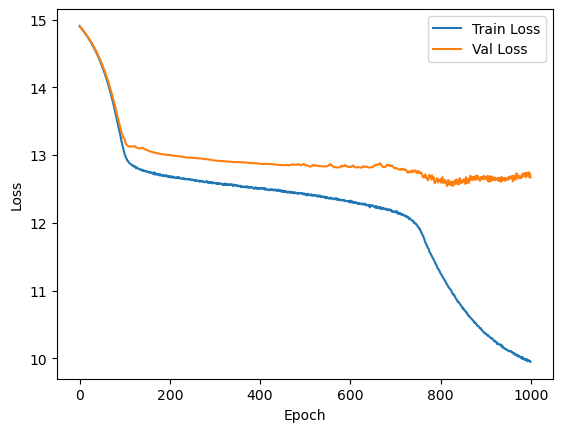

In [7]:
plt.figure() 
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [8]:
# load test edges 
test_edges = pd.read_csv(net_dir + 'removed_edges.csv')
test_edges = test_edges[['src_name', 'dst_name']].rename(columns={'src_name': 'source', 'dst_name': 'target'})
test_edges = test_edges.assign(test_edge=True)
print('# test edges: ', len(test_edges))

# predict all edges 
heads = [] ; tails = [] 
for i in range(len(data.node_names_dict['function'])):
    for j in range(len(data.node_names_dict['function'])):
        heads.append(i)
        tails.append(j)

heads = torch.tensor(heads)
tails = torch.tensor(tails)
relation = torch.zeros(len(heads)) 

dataset = TriplesDataset({'head': heads, 'tail': tails, 'relation': relation})
loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
model = model.to(device)

predictions = []
with torch.no_grad():
    for i, (h,t,r) in enumerate(loader): 
        if (i%100) == 0: print(f'{i}/{len(loader)}', end='\r')
        h = h.to(device)
        t = t.to(device)
        r = r.to(device)
        
        with torch.no_grad():
            logprobs = model(h, r, t)
            predictions.append(logprobs.detach().cpu().numpy() )

predictions = np.concatenate(predictions)


# test edges:  414


/home/exacloud/gscratch/mcweeney_lab/evans/complex2/complex2/data/TriplesDataset.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.pos_heads = torch.tensor(triples['head'], dtype=torch.long)
/home/exacloud/gscratch/mcweeney_lab/evans/complex2/complex2/data/TriplesDataset.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.pos_tails = torch.tensor(triples['tail'], dtype=torch.long)
/home/exacloud/gscratch/mcweeney_lab/evans/complex2/complex2/data/TriplesDataset.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.pos_rel

In [9]:
node_names = np.array(data.node_names_dict['function'])
res = pd.DataFrame({'source': node_names[heads.detach().cpu().numpy()], 
                    'target': node_names[tails.detach().cpu().numpy()], 
                    'prediction': predictions})

# includes train and val edges 
train_edges = pd.DataFrame({'source': node_names[data.edge_index_dict['function', 'to', 'function'][0]], 
                            'target': node_names[data.edge_index_dict['function', 'to', 'function'][1]]})

res = res.merge(train_edges.assign(train_edge=True), on=['source', 'target'], how='left')
res = res.merge(test_edges.assign(test_edge=True), on=['source', 'target'], how='left')

res = res.fillna({'train_edge': False, 'test_edge': False})
res.head()



/tmp/ipykernel_3161701/4104878496.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res = res.fillna({'train_edge': False, 'test_edge': False})


,source,target,prediction,train_edge,test_edge
0,RNA__NUP62,RNA__NUP62,-18.925806,False,False
1,RNA__NUP62,RNA__STMN1,-18.878675,False,False
2,RNA__NUP62,RNA__ANKRD10,-18.922075,False,False
3,RNA__NUP62,RNA__TXNL4B,-18.945370,False,False
4,RNA__NUP62,RNA__NOTCH1,-19.043911,False,False


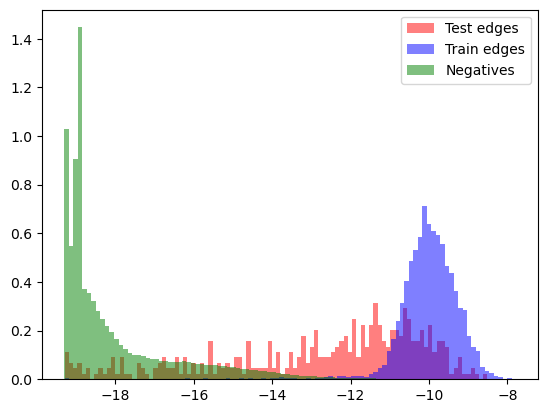

In [10]:
plt.figure() 
plt.hist(res.prediction[res.test_edge], bins=100, color='r', alpha=0.5, label='Test edges', density=True)
plt.hist(res.prediction[res.train_edge], bins=100, color='b', alpha=0.5, label='Train edges', density=True)
plt.hist(res.prediction[~(res.test_edge | res.train_edge)], bins=100, color='g', alpha=0.5, label='Negatives', density=True)
plt.legend()
plt.show()

In [11]:
# top 10 most likely "negative" edges 
res[lambda x: ~(x.train_edge | x.test_edge)].sort_values('prediction', ascending=False).head(10)

,source,target,prediction,train_edge,test_edge
430272,PROTEIN__SRC,PROTEIN__SRC,-7.799261,False,False
2239488,PROTEIN__RXRA,PROTEIN__RXRA,-8.277774,False,False
2847894,PROTEIN__PRKCA,PROTEIN__CREB1,-8.469122,False,False
2849362,PROTEIN__PRKCA,PROTEIN__MDM2,-8.647408,False,False
2126134,PROTEIN__PTPN1,PROTEIN__SHC1,-8.673639,False,False
2347242,PROTEIN__IGF1R,PROTEIN__SRC,-8.690139,False,False
430261,PROTEIN__SRC,PROTEIN__PTPN11,-8.697443,False,False
1554319,PROTEIN__ABL1,PROTEIN__PTK2,-8.700020,False,False
1773700,PROTEIN__MAPK1,PROTEIN__CREB1,-8.712343,False,False
1625581,PROTEIN__FYN,PROTEIN__STAT3,-8.720829,False,False


In [13]:
# use 'has_expr' for subset comparison to spearman and aracne
genes = [x.split('__')[1] for x in data.node_names_dict['output']]
res = res.assign(source_gene = lambda x: x.source.str.split('__').str[1], 
                 target_gene = lambda x: x.target.str.split('__').str[1])
res = res.assign(has_expr = lambda x: x.target_gene.isin(genes) & x.source_gene.isin(genes)) 

res[lambda x: x.has_expr].test_edge.sum()

171

In [14]:
perf_dict = eval_edge_inference(res, data=data, metric='prediction')

/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/lincs-gsnn/lincs_gsnn/utils/eval.py:106: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res['in_tft'] = res['in_tft'].fillna(False).astype(bool)


In [15]:
perf_dict['train']

{'auroc': 0.9972213171172261,
 'aupr': 0.9144215431746462,
 'mrr': 0.8411846313711674,
 'top1_acc': 0.7683080808080808,
 'top10_acc': 0.9816919191919192,
 'top100_acc': 0.9955808080808081,
 'n': 1584}

In [16]:
perf_dict['test']

{'auroc': 0.8828286133183494,
 'aupr': 0.1426649141785922,
 'mrr': 0.3026730831930295,
 'top1_acc': 0.18840579710144928,
 'top10_acc': 0.5797101449275363,
 'top100_acc': 0.7898550724637681,
 'n': 414}

In [17]:
perf_dict['test_tft']

{'auroc': 0.7382761290575786,
 'aupr': 0.10882454386303746,
 'mrr': 0.05860629005011918,
 'top1_acc': 0.020193861066235864,
 'top10_acc': 0.13018309100700054,
 'top100_acc': 0.4123586429725363,
 'n': 7428}

In [18]:
perf_dict['test_tft_isolate']

{'auroc': 0.5554564493448949,
 'aupr': 0.008862723288418388,
 'mrr': 0.02620333347260189,
 'top1_acc': 0.0,
 'top10_acc': 0.06173526140155729,
 'top100_acc': 0.2836484983314794,
 'n': 1798}

In [19]:
perf_dict['test_has_expr']

{'auroc': 0.9422765195477076,
 'aupr': 0.1985466834374585,
 'mrr': 0.344653562332968,
 'top1_acc': 0.17543859649122806,
 'top10_acc': 0.7368421052631579,
 'top100_acc': 0.8830409356725146,
 'n': 171}

In [20]:
perf_dict['neg']

{'auroc': None,
 'aupr': None,
 'mrr': 0.008366360015142314,
 'top1_acc': 0.0,
 'top10_acc': 0.012174119931888005,
 'top100_acc': 0.13392361884394965,
 'n': 722927}

# Comparison with OEI (06a)

In [21]:
res_complex2 = pd.read_csv(f'{root_dir}/complex2_results.csv')[['source', 'target', 'test_edge', 'train_edge', 'prediction', 'rank']].rename(columns={'rank': 'rank_complex2'})
res_oei = pd.read_csv(f'{root_dir}/OEI_results.csv')[['source', 'target', 'prob', 'rank']].rename(columns={'rank': 'rank_oei'})
ress = res_complex2.merge(res_oei, on=['source', 'target'], how='outer')
ress = ress.fillna(False)
ress.head()

/tmp/ipykernel_3161701/670607654.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ress = ress.fillna(False)


,source,target,test_edge,train_edge,prediction,rank_complex2,prob,rank_oei
0,PROTEIN__AAK1,RNA__ABL1,False,False,-16.388062,261.0,0.010521,486.0
1,PROTEIN__AAK1,RNA__ACAT2,False,False,-15.725286,117.0,0.017828,482.0
2,PROTEIN__AAK1,RNA__ACLY,False,False,-16.95587,454.0,0.008093,484.0
3,PROTEIN__AAK1,RNA__ADAM10,False,False,-17.87997,472.0,0.022407,509.0
4,PROTEIN__AAK1,RNA__ADGRE5,False,False,-19.286678,682.0,0.012615,493.0


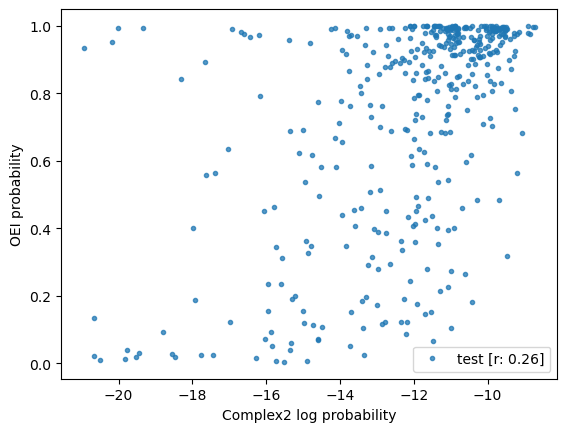

In [22]:
plt.figure() 
r = ress[['prediction', 'prob']].corr().iloc[0,1]
plt.plot(ress[lambda x: x.test_edge]['prediction'].values.astype(float), ress[lambda x: x.test_edge]['prob'], '.', label=f'test [r: {r:.2f}]', alpha=0.75)
plt.xlabel('Complex2 log probability')
plt.ylabel('OEI probability')
plt.legend()
plt.show()


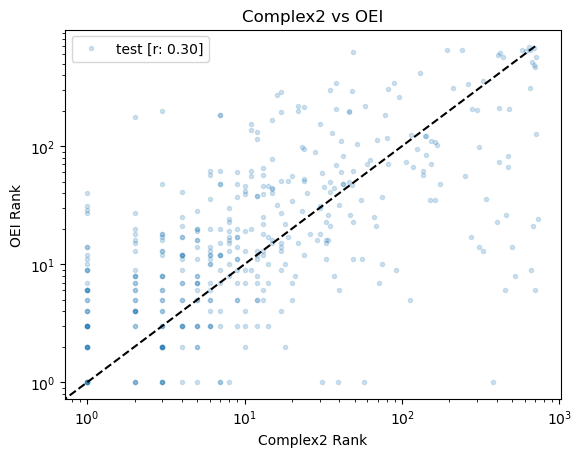

In [23]:
plt.figure() 
r = ress[['rank_complex2', 'rank_oei']].corr().iloc[0,1]
plt.plot(ress[lambda x: x.test_edge]['rank_complex2'], ress[lambda x: x.test_edge]['rank_oei'], '.', label=f'test [r: {r:.2f}]', alpha=0.2)
plt.xlabel('Complex2 Rank')
plt.ylabel('OEI Rank')
plt.title('Complex2 vs OEI')
plt.plot([0, 700], [0, 700], 'k--')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()
